### Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from scipy.optimize import dual_annealing
import matplotlib.pyplot as plt
import itertools
from scipy.stats import ttest_rel
from sklearn.model_selection import learning_curve
import seaborn as sns

### Import Cleaned CSV

In [2]:
final_df = pd.read_csv('./new_dataset/cleaned_data_unscaled.csv')

y = final_df["productivity_score"]
X = final_df.drop(columns = ["productivity_score"])

### Split Data (Train and Test)

In [3]:
# split dataset into training and test sets (random_state ensures reproducible results)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print("Training set:", X_trainval.shape)
print("Test set:", X_test.shape)

Training set: (3600, 21)
Test set: (900, 21)


### Baseline Model (Mean Predictor)

In [4]:
# baseline predicting the training mean for the test set
y_pred_baseline = np.full(len(y_test), y_trainval.mean())

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R^2: {baseline_r2:.4f}")

Baseline MAE: 11.25
Baseline RMSE: 14.11
Baseline R^2: -0.0004


### Configurations

In [5]:
cols_to_exclude = ["job_role_Designer", "job_role_Developer", "job_role_Manager", "job_role_Marketer", "job_role_Writer", "deadline_pressure_level_Low", "deadline_pressure_level_Medium", "deadline_pressure_level_High"]
cols_to_scale = X_trainval.columns.difference(cols_to_exclude)

k = 5
kf = KFold(n_splits = k, shuffle = True, random_state = 42)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

preprocess = ColumnTransformer(
    transformers = [("num", StandardScaler(), cols_to_scale)],
    remainder = "passthrough"
)

### Search Spaces for Simulated Annealing

In [6]:
search_spaces = {

    # alpha: 0.0001 – 100, low = weak regularization, high = strong regularization
    "ridge_l2": {
        "bounds": [(0.0001, 100.0)],
        "build_model": lambda p: Ridge(alpha = p[0]),
    },

    # max_depth: 2 – 30, low = shallow/underfitting, high = deep/overfitting
    # min_samples_split: 2 – 40, low = more splits/complex tree, high = fewer splits/simpler tree
    # min_samples_leaf: 1 – 20, low = small leaves/overfitting, high = large leaves/generalization
    "decision_tree": {
        "bounds": [(2, 30), (2, 40), (1, 20)],
        "build_model": lambda p: DecisionTreeRegressor(
            max_depth = int(p[0]), min_samples_split = int(p[1]),
            min_samples_leaf = int(p[2]), random_state = 42
        ),
    },

    # n_estimators: 50 – 1000, low = fewer trees/underfitting, high = more trees/slower training
    # learning_rate: 0.001 – 0.3, low = small steps/needs more trees, high = large steps/risk overfitting
    # max_depth: 2 – 12, low = shallow trees/underfitting, high = deep trees/overfitting
    # subsample: 0.5 – 1.0, low = more randomness/regularization, high = use all rows
    # colsample_bytree: 0.5 – 1.0, low = more randomness/regularization, high = use all features
    "xgboost": {
        "bounds": [(50, 1000), (1e-3, 0.3), (2, 12), (0.5, 1.0), (0.5, 1.0)],
        "build_model": lambda p: XGBRegressor(
            n_estimators = int(p[0]), learning_rate = p[1],
            max_depth = int(p[2]), subsample = p[3],
            colsample_bytree = p[4], random_state = 42
        ),
    },

    # layer1 neurons: 16 – 128, low = less capacity/underfitting, high = more capacity/overfitting
    # layer2 neurons: 8 – 64, low = less capacity/underfitting, high = more capacity/overfitting
    # alpha (L2 penalty): 0.000001 – 0.1, low = weak regularization, high = strong regularization
    # learning_rate_init: 0.0001 – 0.01, low = slow/stable training, high = fast/unstable training
    "neural_net": {
        "bounds": [(1, 4), (16, 128), (8, 64), (8, 32), (4, 16), (0.000001, 0.1), (0.0001, 0.01)],
        "build_model": lambda p: MLPRegressor(
            hidden_layer_sizes = tuple(int(p[i + 1]) for i in range(int(p[0]))),
            activation = "relu", solver = "adam", alpha = p[5],
            learning_rate_init = p[6], max_iter = 2000,
            early_stopping = True, random_state = 42
        ),
    },
}

### Objective Function

In [7]:
# params: array of numbers that simulated annealing proposed
# takes that array and constructs a model object with those hyperparameters
def objective(params, build_model):
    model = build_model(params)
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    scores = cross_validate(pipe, X_trainval, y_trainval, cv = kf, scoring = scoring)
    return -scores["test_r2"].mean()

# dual annealing tries to find the lowest value (it is a minimizer) but we want the highest R2 so we flip it

### K-Folds and Training

In [8]:
results = {}
model_cv_scores = {}
best_sa_params = {}

# Store results for visualization with error bars
cv_results = {
    "model": [],
    "mae_mean": [], "mae_std": [],
    "rmse_mean": [], "rmse_std": [],
    "r2_mean": [], "r2_std": []
}

## linear model does not need tuning
print("linear_regression (no tuning)")
pipe = Pipeline([("preprocess", preprocess), ("model", LinearRegression())])
scores = cross_validate(pipe, X_trainval, y_trainval, cv = kf, scoring = scoring)

mae = -scores["test_mae"]
rmse = -scores["test_rmse"]
r2 = scores["test_r2"]

print(f"  MAE : {mae.mean():.4f} ± {mae.std():.4f}")
print(f"  RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}")
print(f"  R^2 : {r2.mean():.4f} ± {r2.std():.4f}\n")

results["linear_regression"] = r2.mean()
model_cv_scores["linear_regression"] = scores["test_r2"]

cv_results["model"].append("linear_regression")
cv_results["mae_mean"].append(mae.mean())
cv_results["mae_std"].append(mae.std())
cv_results["rmse_mean"].append(rmse.mean())
cv_results["rmse_std"].append(rmse.std())
cv_results["r2_mean"].append(r2.mean())
cv_results["r2_std"].append(r2.std())

for name, space in search_spaces.items():
    print(f"{name} — running simulated annealing...")

    result = dual_annealing(
        objective,
        bounds = space["bounds"],
        args = (space["build_model"],),
        maxiter = 50,
        seed = 42
    )

    # final eval with best params
    best_model = space["build_model"](result.x)
    pipe = Pipeline([("preprocess", preprocess), ("model", best_model)])
    final = cross_validate(pipe, X_trainval, y_trainval, cv = kf, scoring = scoring)

    mae  = -final["test_mae"]
    rmse = -final["test_rmse"]
    r2   =  final["test_r2"]

    print(f"  Best params: {np.round(result.x, 4)}")
    print(f"  MAE : {mae.mean():.4f} ± {mae.std():.4f}")
    print(f"  RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}")
    print(f"  R^2  : {r2.mean():.4f} ± {r2.std():.4f}\n")
    
    results[name] = r2.mean()
    model_cv_scores[name] = r2
    best_sa_params[name] = result.x
    
    cv_results["model"].append(name)
    cv_results["mae_mean"].append(mae.mean())
    cv_results["mae_std"].append(mae.std())
    cv_results["rmse_mean"].append(rmse.mean())
    cv_results["rmse_std"].append(rmse.std())
    cv_results["r2_mean"].append(r2.mean())
    cv_results["r2_std"].append(r2.std())

print("FINAL COMPARISON (sorted by R^2)")
for name, r2 in sorted(results.items(), key = lambda x: x[1], reverse=True):
    print(f"  {name:<20s}  R^2 = {r2:.4f}")

linear_regression (no tuning)
  MAE : 4.0139 ± 0.0774
  RMSE: 5.0261 ± 0.1511
  R^2 : 0.8769 ± 0.0065

ridge_l2 — running simulated annealing...
  Best params: [4.1785]
  MAE : 4.0133 ± 0.0756
  RMSE: 5.0258 ± 0.1499
  R^2  : 0.8769 ± 0.0064

decision_tree — running simulated annealing...
  Best params: [10.2978  2.6228 11.6975]
  MAE : 5.9994 ± 0.1011
  RMSE: 7.5083 ± 0.1144
  R^2  : 0.7255 ± 0.0066

xgboost — running simulated annealing...
  Best params: [8.216479e+02 1.680000e-02 2.413500e+00 6.117000e-01 7.529000e-01]
  MAE : 4.1715 ± 0.0932
  RMSE: 5.2355 ± 0.1440
  R^2  : 0.8665 ± 0.0049

neural_net — running simulated annealing...
  Best params: [2.86750e+00 2.21133e+01 1.24915e+01 1.86176e+01 4.43950e+00 8.40000e-02
 7.40000e-03]
  MAE : 4.0657 ± 0.1095
  RMSE: 5.1160 ± 0.1876
  R^2  : 0.8724 ± 0.0086

FINAL COMPARISON (sorted by R^2)
  ridge_l2              R^2 = 0.8769
  linear_regression     R^2 = 0.8769
  neural_net            R^2 = 0.8724
  xgboost               R^2 = 0.86

### Statistical Significance Test

In [9]:
print("\nStatistical significance tests (paired t-test on CV folds)\n")

for m1, m2 in itertools.combinations(model_cv_scores.keys(), 2):

    scores1 = model_cv_scores[m1]
    scores2 = model_cv_scores[m2]

    t_stat, p_value = ttest_rel(scores1, scores2)

    print(f"{m1} vs {m2}")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value     = {p_value:.4f}")

    if p_value < 0.05:
        print("Result: statistically significant difference\n")
    else:
        print("Result: no statistically significant difference\n")


Statistical significance tests (paired t-test on CV folds)

linear_regression vs ridge_l2
t-statistic = -0.3466
p-value     = 0.7463
Result: no statistically significant difference

linear_regression vs decision_tree
t-statistic = 69.0850
p-value     = 0.0000
Result: statistically significant difference

linear_regression vs xgboost
t-statistic = 8.4333
p-value     = 0.0011
Result: statistically significant difference

linear_regression vs neural_net
t-statistic = 3.7732
p-value     = 0.0195
Result: statistically significant difference

ridge_l2 vs decision_tree
t-statistic = 69.4031
p-value     = 0.0000
Result: statistically significant difference

ridge_l2 vs xgboost
t-statistic = 8.6461
p-value     = 0.0010
Result: statistically significant difference

ridge_l2 vs neural_net
t-statistic = 3.6941
p-value     = 0.0209
Result: statistically significant difference

decision_tree vs xgboost
t-statistic = -51.5480
p-value     = 0.0000
Result: statistically significant difference

decisio

### Model Comparison (Error Bars)

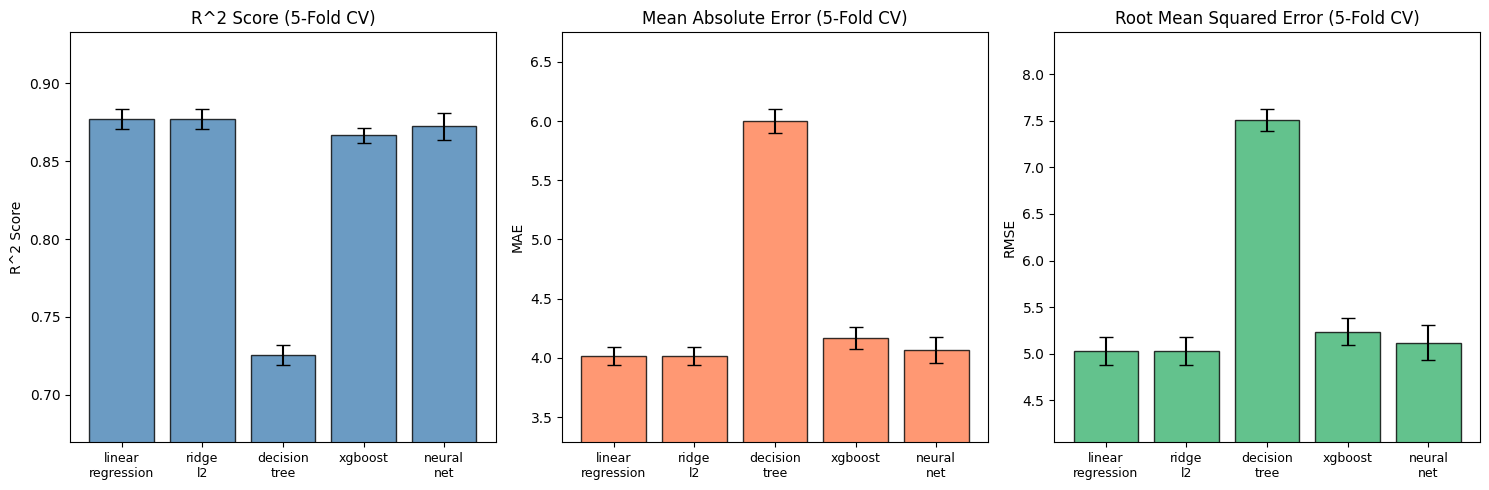

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x = np.arange(len(cv_results["model"]))
model_labels = [m.replace("_", "\n") for m in cv_results["model"]]

# Helper to compute zoomed y-limits with padding
def get_ylim_zoomed(means, stds, pad_factor=0.3):
    lower = min(m - s for m, s in zip(means, stds))
    upper = max(m + s for m, s in zip(means, stds))
    range_val = upper - lower
    padding = range_val * pad_factor
    return max(0, lower - padding), upper + padding

# R^2 Score (zoomed to show differences)
r2_ylim = get_ylim_zoomed(cv_results["r2_mean"], cv_results["r2_std"])
axes[0].bar(x, cv_results["r2_mean"], yerr=cv_results["r2_std"], capsize=5, 
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels, fontsize=9)
axes[0].set_ylabel('R^2 Score')
axes[0].set_title('R^2 Score (5-Fold CV)')
axes[0].set_ylim(r2_ylim)

# MAE (zoomed)
mae_ylim = get_ylim_zoomed(cv_results["mae_mean"], cv_results["mae_std"])
axes[1].bar(x, cv_results["mae_mean"], yerr=cv_results["mae_std"], capsize=5,
            color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels, fontsize=9)
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error (5-Fold CV)')
axes[1].set_ylim(mae_ylim)

# RMSE (zoomed)
rmse_ylim = get_ylim_zoomed(cv_results["rmse_mean"], cv_results["rmse_std"])
axes[2].bar(x, cv_results["rmse_mean"], yerr=cv_results["rmse_std"], capsize=5,
            color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_labels, fontsize=9)
axes[2].set_ylabel('RMSE')
axes[2].set_title('Root Mean Squared Error (5-Fold CV)')
axes[2].set_ylim(rmse_ylim)

plt.tight_layout()
plt.savefig('./data_analysis/model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.savefig('./data_analysis/model_comparison_cv.pdf', bbox_inches='tight')
plt.show()

### Final Evaluation

In [11]:
best_model_name = max(results, key=results.get)

if best_model_name == "linear_regression":
    best_model = LinearRegression()
else:
    best_model = search_spaces[best_model_name]["build_model"](best_sa_params[best_model_name])

final_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", best_model)
])

final_pipe.fit(X_trainval, y_trainval)
test_preds = final_pipe.predict(X_test)

mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
r2 = r2_score(y_test, test_preds)

print(f"Final Test on: {best_model_name}")
print(f"Best alpha from simulated annealing: {np.round(best_sa_params[best_model_name], 4)}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 : {r2:.4f}")

Final Test on: ridge_l2
Best alpha from simulated annealing: [4.1785]
MAE : 3.9428
RMSE: 4.9105
R^2 : 0.8788


### Residual analysis


Residual statistics:
Residual mean: 0.009965375545938333
Residual std : 4.913179144511993


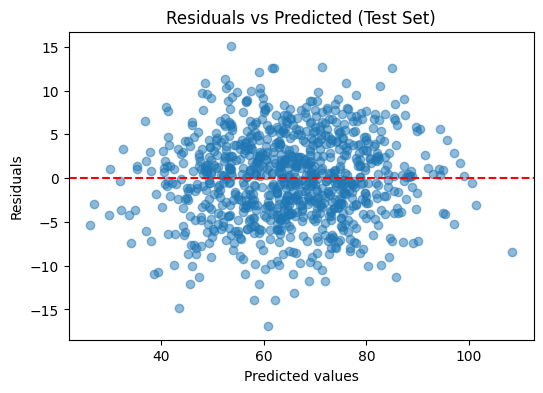

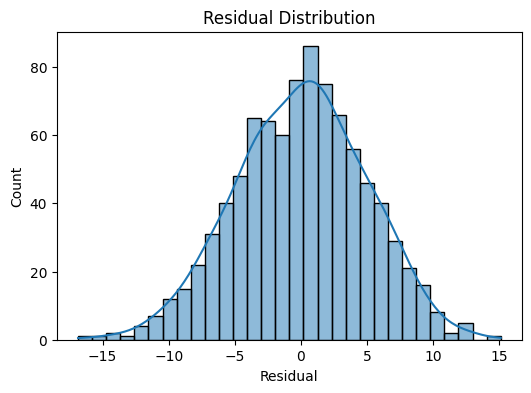

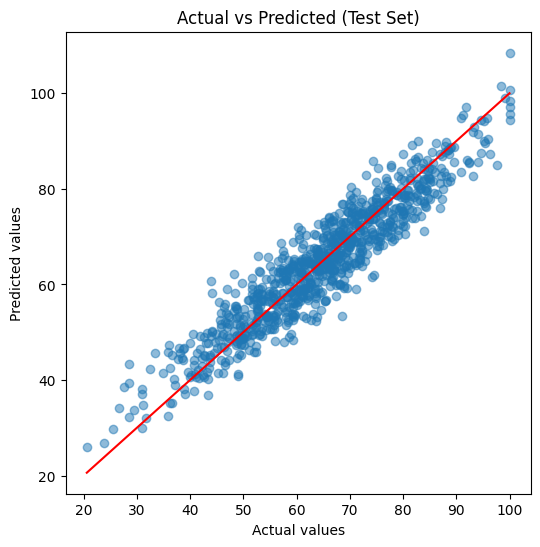

In [13]:
residuals = y_test - test_preds

print("\nResidual statistics:")
print("Residual mean:", residuals.mean())
print("Residual std :", residuals.std())


# residuals vs predicted
plt.figure(figsize=(6,4))
plt.scatter(test_preds, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test Set)")

plt.savefig("./data_analysis/residual_vs_predicted.png", bbox_inches = "tight")
plt.savefig("./data_analysis/residual_vs_predicted.pdf", bbox_inches = "tight")

plt.show()


# residual distribution
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)

plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.savefig("./data_analysis/residual_distribution.png", bbox_inches = "tight")
plt.savefig("./data_analysis/residual_distribution.pdf", bbox_inches = "tight")

plt.show()


# actual vs predicted
plt.figure(figsize=(6,6))

plt.scatter(y_test, test_preds, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted (Test Set)")

plt.savefig("./data_analysis/actual_vs_predicted.png", bbox_inches = "tight")
plt.savefig("./data_analysis/actual_vs_predicted.pdf", bbox_inches = "tight")

plt.show()

### Printing Ridge Coefficients

In [14]:
ridge_model = final_pipe.named_steps["model"]
feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()

coefficients = ridge_model.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending = False)

print("\nRidge coefficients:")
print(coef_df[["feature", "coefficient"]].to_string(index = False))


Ridge coefficients:
                                  feature  coefficient
             num__tasks_automated_percent     7.361327
                    num__experience_years     5.685389
                 num__focus_hours_per_day     5.488753
                  num__error_rate_percent    -4.633625
                  num__burnout_risk_score    -4.563440
             num__work_life_balance_score    -0.742020
          num__manual_work_hours_per_week    -0.608878
   remainder__deadline_pressure_level_Low     0.593393
  remainder__deadline_pressure_level_High    -0.511359
        num__ai_tool_usage_hours_per_week    -0.398304
              num__meeting_hours_per_week    -0.355415
               remainder__job_role_Writer    -0.283127
             remainder__job_role_Marketer     0.170773
            remainder__job_role_Developer    -0.153341
             remainder__job_role_Designer     0.142277
              remainder__job_role_Manager     0.127266
        num__learning_time_hours_per_week   

### Bar Graph

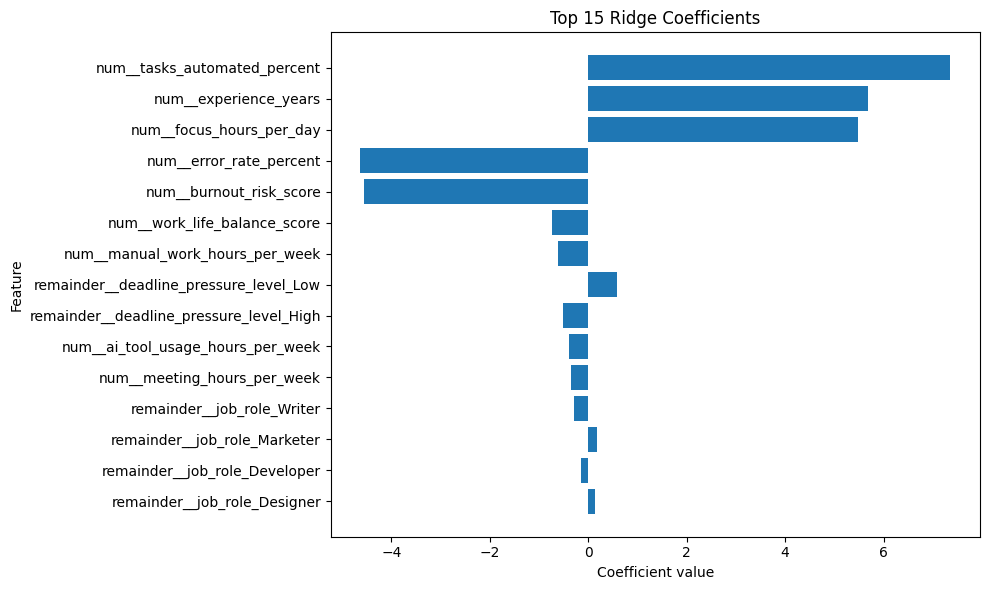

In [15]:
top_n = 15
top_coef_df = coef_df.head(top_n)

plt.figure(figsize = (10, 6))
plt.barh(top_coef_df["feature"], top_coef_df["coefficient"])
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Ridge Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("./data_analysis/bar_graph.png", bbox_inches = "tight")
plt.savefig("./data_analysis/bar_graph.png", bbox_inches = "tight")

plt.show()

### Learning curves (Best performing model L2 Ridge)

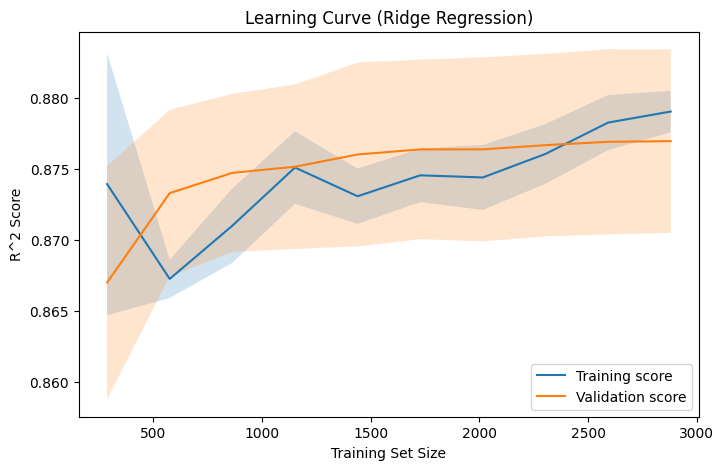

In [16]:
model = Ridge(alpha = 1.0)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

train_sizes, train_scores, val_scores = learning_curve(
    pipe,
    X_trainval,
    y_trainval,
    cv = kf,
    scoring = "r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs = -1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))

plt.plot(train_sizes, train_mean, label = "Training score")
plt.plot(train_sizes, val_mean, label = "Validation score")

plt.fill_between(train_sizes,
                 train_mean-train_std,
                 train_mean+train_std,
                 alpha = 0.2)

plt.fill_between(train_sizes,
                 val_mean-val_std,
                 val_mean+val_std,
                 alpha = 0.2)

plt.xlabel("Training Set Size")
plt.ylabel("R^2 Score")
plt.title("Learning Curve (Ridge Regression)")
plt.legend()

plt.savefig("./data_analysis/learning_curve.png", bbox_inches = "tight")
plt.savefig("./data_analysis/learning_curve.pdf", bbox_inches = "tight")

plt.show()